# Analiza slovenskih gora

V nadaljevanju bomo analizirali podatke o slovenskih gorah, zbrane s spletne strani [hribi.net](https://www.hribi.net). Za vsako goro imamo podatke o njenem imenu, gorovju, v katerem leži, višini, številu ogledov na spletni strani, priljubljenosti (v %) ter o poteh, ki vodijo do vrha. Za vsako pot poznamo njeno ime, predviden čas hoje (v minutah) in zahtevnost.

Analiza bo sestavljena iz dveh delov:
- analiza gorovij in poti,
- analiza gora.

Najprej uvozimo podatke iz datotek `gore.csv` in `poti.csv`.

In [1]:
import pandas as pd
gore = pd.read_csv("gore.csv", index_col="id")
poti = pd.read_csv("poti.csv", index_col="gora_id")

Tako zdaj izgledajo naši podatki o gorah.

In [2]:
gore

,ime,gorovje,visina,ogledi,priljubljenost,stevilo_poti
id,,,,,,
1,Veliki Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1796,1052077,99,10
2,Mali Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1694,439327,86,4
3,Mali Golak,"Goriško, Notranjsko in Snežniško hribovje",1495,710879,98,7
4,Srednji Golak,"Goriško, Notranjsko in Snežniško hribovje",1480,403846,83,2
5,Smrekov vrh,"Goriško, Notranjsko in Snežniško hribovje",1449,4490,40,1
...,...,...,...,...,...,...
2471,Ormoško jezero,"Strojna, Košenjak, Kozjak in Slovenske gorice",186,308,15,1
2472,Babičev mlin na Muri,"Strojna, Košenjak, Kozjak in Slovenske gorice",182,1843,31,2
2473,Gramoznica Krapje,"Strojna, Košenjak, Kozjak in Slovenske gorice",180,61,3,1


In tako podatki o poteh.

In [3]:
poti

,ime,cas,zahtevnost
gora_id,,,
1,Sviščaki - Veliki Snežnik,130,lahka označena pot
1,Kapetanova bajta - Veliki Snežnik,55,lahka označena pot
1,Leskova dolina - Veliki Snežnik,195,lahka označena pot
1,Snežniška Grda jama - Veliki Snežnik (čez Mali...,85,lahka označena pot
1,Gašperjev hrib - Veliki Snežnik,90,lahka označena pot
...,...,...,...
2472,Beltinci - Babičev mlin na Muri,95,lahka označena pot
2473,Zgornje Krapje - Gramoznica Krapje,20,lahka neoznačena steza
2474,Mota - Brod na Muri (Melinci) (od mrtvic do reke),45,lahka označena pot


## Analiza gorovij in poti

Ker posameznih gora ni smiselno obravnavati ločeno, bomo najprej pogledali njihove značilnosti na ravni gorovij. Zanima nas predvsem, kako se gorovja razlikujejo po številu gora, višini, priljubljenosti in številu ogledov.

Najprej gore razvrstimo glede na gorovje, v katerem ležijo.

> Opomba: Poimenovanja na spletni strani niso povsem geografsko natančna. Gre bolj za regije kot pa za klasična gorovja, vendar bomo zaradi skladnosti z virom uporabljali izraz *gorovje*.

In [4]:
gorovja = gore.groupby("gorovje").size().sort_values(ascending=False)
gorovja

gorovje
Julijske Alpe                                    613
Karavanke                                        394
Goriško, Notranjsko in Snežniško hribovje        309
Posavsko hribovje in Dolenjska                   307
Kamniško Savinjske Alpe                          297
Škofjeloško, Cerkljansko hribovje in Jelovica    145
Pohorje, Dravinjske gorice in Haloze             128
Strojna, Košenjak, Kozjak in Slovenske gorice    115
Polhograjsko hribovje in Ljubljana                92
Prekmurje                                         75
dtype: int64

<Axes: title={'center': 'Delež gora po gorovjih'}>

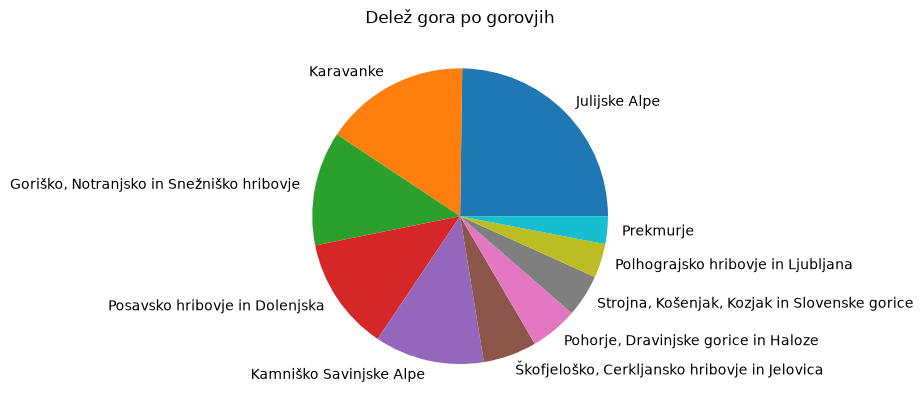

In [5]:
gorovja.plot.pie(title="Delež gora po gorovjih")

Poglejmo koliko je povprečna višina posameznega gorovja, katero je najbolj priljbljeno in kolikšno je skupno število ogledov gor za vsako gorovje posebej.

In [6]:
gore.groupby("gorovje")["visina"].mean().round().sort_values(ascending=False)

gorovje
Julijske Alpe                                    1645.0
Kamniško Savinjske Alpe                          1349.0
Karavanke                                        1273.0
Škofjeloško, Cerkljansko hribovje in Jelovica     956.0
Pohorje, Dravinjske gorice in Haloze              913.0
Goriško, Notranjsko in Snežniško hribovje         764.0
Posavsko hribovje in Dolenjska                    644.0
Polhograjsko hribovje in Ljubljana                622.0
Strojna, Košenjak, Kozjak in Slovenske gorice     531.0
Prekmurje                                         295.0
Name: visina, dtype: float64

In [7]:
gore.groupby("gorovje")["priljubljenost"].mean().round().sort_values(ascending=False)

gorovje
Kamniško Savinjske Alpe                          72.0
Julijske Alpe                                    70.0
Polhograjsko hribovje in Ljubljana               67.0
Goriško, Notranjsko in Snežniško hribovje        63.0
Škofjeloško, Cerkljansko hribovje in Jelovica    60.0
Karavanke                                        59.0
Posavsko hribovje in Dolenjska                   50.0
Pohorje, Dravinjske gorice in Haloze             41.0
Strojna, Košenjak, Kozjak in Slovenske gorice    31.0
Prekmurje                                        24.0
Name: priljubljenost, dtype: float64

In [8]:
gore.groupby("gorovje")["ogledi"].sum().round().sort_values(ascending=False)

gorovje
Julijske Alpe                                    198472084
Kamniško Savinjske Alpe                          105212522
Karavanke                                         90456706
Goriško, Notranjsko in Snežniško hribovje         72249185
Posavsko hribovje in Dolenjska                    51147035
Škofjeloško, Cerkljansko hribovje in Jelovica     31572421
Polhograjsko hribovje in Ljubljana                25419682
Pohorje, Dravinjske gorice in Haloze              14713746
Strojna, Košenjak, Kozjak in Slovenske gorice      6104134
Prekmurje                                          1953776
Name: ogledi, dtype: int64

Iz rezultatov je razvidno, da višina gorovja močno vpliva na število ogledov, vendar pa ne določa nujno tudi priljubljenosti. Najvišja gorovja (Julijske Alpe, Kamniško-Savinjske Alpe in Karavanke) imajo največ ogledov, medtem ko se priljubljenost med njimi nekoliko razlikuje. Nižja in vzhodnejša gorovja imajo tako nižje vrednosti pri vseh treh lastnostih.

Poleg lastnosti gorovij so zanimive tudi lastnosti poti, ki vodijo do njihovih vrhov. Najprej si oglejmo, kako so poti porazdeljene glede na predviden čas hoje. Ker je posameznih poti veliko, jih za preglednejšo analizo razdelimo v časovne razrede po 30 minut. Posamezen razred bo označen s svojo spodnjo mejo.

<Axes: title={'center': 'Porazdelitev časa poti'}, xlabel='Čas v minutah', ylabel='Število poti'>

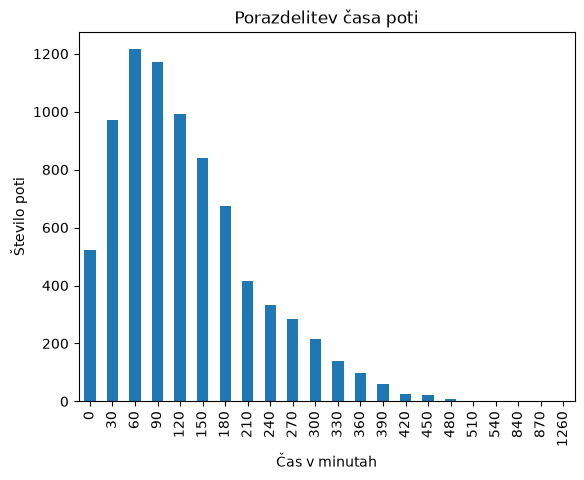

In [52]:
poti_po_casih = ((poti["cas"] // 30) * 30).value_counts().sort_index()
poti_po_casih.plot.bar(
    xlabel="Čas v minutah",
    ylabel="Število poti",
    title="Porazdelitev časa poti"
)

Iz grafa razberemo, da za veliko večino poti potrebujemo od 30 do 150 minut, poti daljših od 6 ur pa je zelo malo.

Poglejmo še zahtevnost poti. Ker lahko posamezna pot pripada več kategorijam zahtevnosti, bomo prešteli pojavitve posameznih zahtevnosti v opisih poti.

In [53]:
lahke = poti["zahtevnost"].str.contains("lahka").sum()
zelo_zahtevne = poti["zahtevnost"].str.contains("zelo zahtevna").sum()
zahtevne = poti["zahtevnost"].str.contains("zahtevna").sum() - zelo_zahtevne

<Axes: title={'center': 'Število poti po zahtevnosti'}, xlabel='Zahtevnost', ylabel='Število poti'>

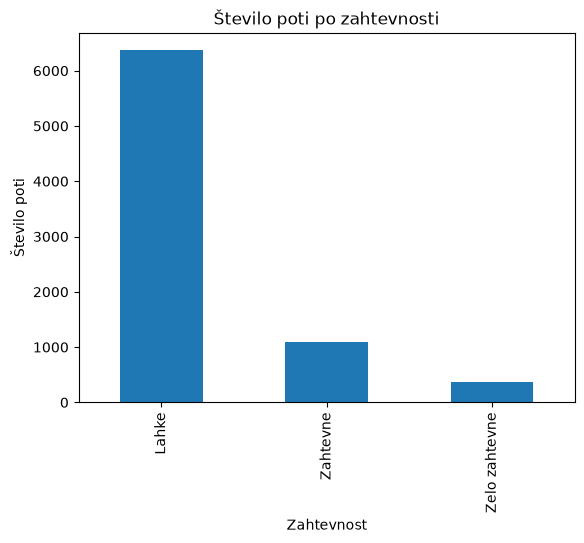

In [54]:
zahtevnosti = pd.Series([lahke, zahtevne, zelo_zahtevne], index=["Lahke", "Zahtevne", "Zelo zahtevne"])
zahtevnosti.plot.bar(
    title="Število poti po zahtevnosti",
    xlabel="Zahtevnost",
    ylabel="Število poti"
)

Vidimo, da je večina poti lahkih, zahtevnih je manj, zelo zahtevnih pa le peščica.

## Analiza gora

Analizo gora začnimo s pregledom najvišjih slovenskih vrhov in njihove priljubljenosti.

In [55]:
gore.sort_values("visina", ascending=False)[["ime", "visina", "priljubljenost"]].head(10)

,ime,visina,priljubljenost
id,,,
310,Triglav,2864,100
311,Montaž / Jôf di Montasio,2753,98
312,Škrlatica,2740,99
313,Mali Triglav,2725,93
314,Mangart,2679,99
315,Viš/Jof Fuart,2666,97
316,Vrh Brda / Cima Verde,2661,88
317,Visoki Rokav,2646,93
318,Jalovec,2645,99


Med desetimi najvišjimi gorami so vse zelo priljubljene, saj njihova priljubljenost presega 90%. To nakazuje, da so najvišji slovenski vrhovi med obiskovalci dobro poznani in pogosto obiskani.

Sedaj poglejmo kako je z odvisnostjo priljubljenosti od višine za vse gore. Ker posamezne gore močno odstopajo, jih razdelimo v višinske razrede po 500 metrov in primerjamo priljubljenosti znotraj posameznega razreda.

In [56]:
visinski_razredi = gore["visina"] // 500 * 500

<Axes: title={'center': 'Povprečna priljubljenost po višinskih razredih (500 m)'}, xlabel='Višinski razred', ylabel='Priljubljenost'>

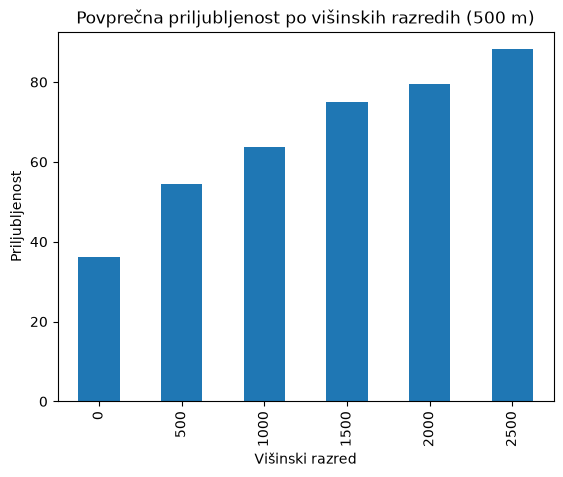

In [57]:
priljubljenost_po_visini = gore.groupby(visinski_razredi)["priljubljenost"].mean()
priljubljenost_po_visini.plot.bar(
    title="Povprečna priljubljenost po višinskih razredih (500 m)",
    xlabel="Višinski razred",
    ylabel="Priljubljenost"
)

Videti je, da so višje gore res bolj priljubljene. To je verjetno povezano z dejstvom, da se med višjimi gorami nahaja več znanih in pogosto obiskanih vrhov.

Zanima nas tudi, koliko časa v povprečju traja vzpon na goro glede na njeno višino. Za vsako goro zato izračunamo povprečen čas vseh dostopnih poti in ga združimo s podatki o gorah, da lahko primerjamo čas vzpona med različnimi višinskimi razredi.

In [58]:
gore2 = gore.join(poti.groupby("gora_id")["cas"].mean())

<Axes: title={'center': 'Povprečen čas poti po višinskih razredih (500 m)'}, xlabel='Višinski razred', ylabel='Povprečen čas poti'>

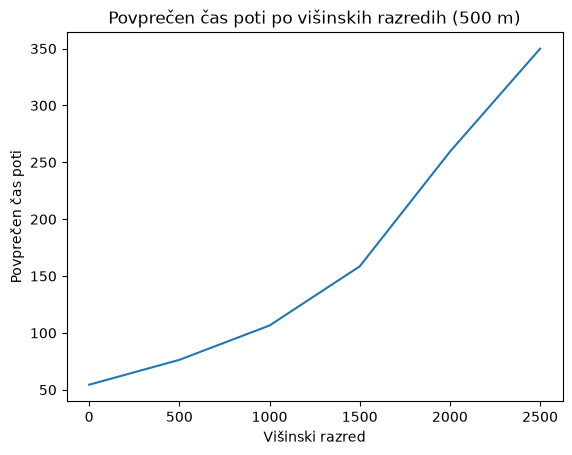

In [59]:
povprecen_cas_po_visini = gore2.groupby(visinski_razredi)["cas"].mean().sort_index()
povprecen_cas_po_visini.plot(
    title="Povprečen čas poti po višinskih razredih (500 m)",
    xlabel="Višinski razred",
    ylabel="Povprečen čas poti"
)

Po pričakovanju so višje gore v povprečju dostopne po daljših poteh. To je smiselno, saj višji vrhovi običajno zahtevajo večji višinski vzpon in so pogosto bolj oddaljeni od izhodišč.

Oglejmo si še, ali imajo višje gore več poti.

<Axes: title={'center': 'Povprečno število poti po višinskih razredih (500 m)'}, xlabel='Višinski razred', ylabel='Povprečno število poti'>

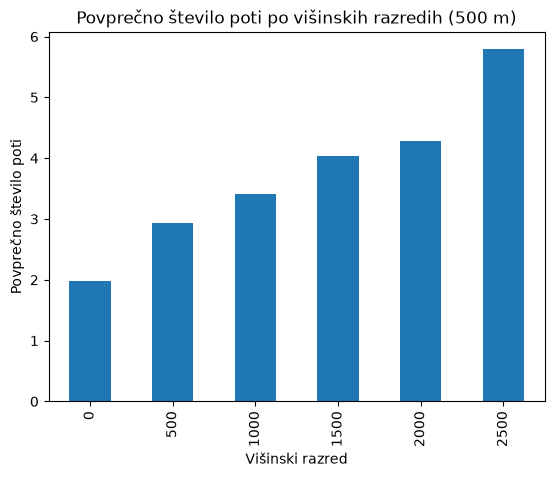

In [60]:
poti_po_visini = gore.groupby(visinski_razredi)["stevilo_poti"].mean().sort_index()
poti_po_visini.plot.bar(
    title="Povprečno število poti po višinskih razredih (500 m)",
    xlabel="Višinski razred",
    ylabel="Povprečno število poti"
)

Očitno imajo višje gore v povprečju več označenih poti, kar je verjetno povezano z njihovo večjo priljubljenostjo med planinci. Posledično se skozi čas razvije več različnih možnosti dostopa do vrha iz različnih izhodišč.

Poglejmo povezavo med priljubljenostjo gore in številom poti.

<Axes: title={'center': 'Priljubljenost glede na število poti'}, xlabel='stevilo_poti', ylabel='priljubljenost'>

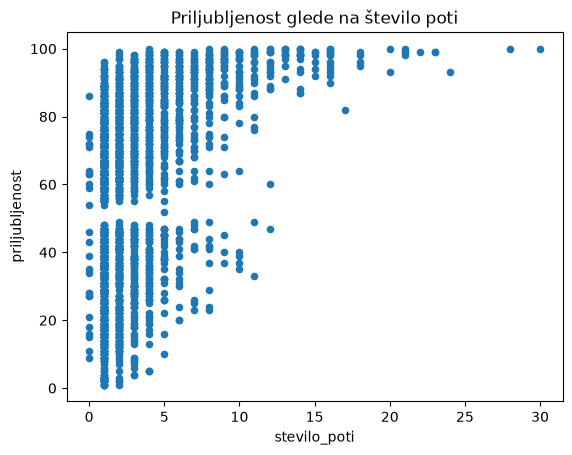

In [62]:
gore.plot.scatter(
    title="Priljubljenost glede na število poti",
    x="stevilo_poti",
    y="priljubljenost"
)

Opazimo, da so gore z majhnim številom poti lahko tako zelo nepriljubljene kot tudi zelo priljubljene, zato med njimi ni jasnega vzorca. Po drugi strani pa so gore z velikim številom dostopnih poti praviloma zelo priljubljene. To nakazuje, da je večja dostopnost pogosto povezana z večjo obiskanostjo in zanimanjem planincev.

## Zaključek

Analiza podatkov je pokazala, da se slovenska gorovja med seboj precej razlikujejo tako po svojih geografskih značilnostih kot tudi po zanimanju obiskovalcev. Višja gorovja praviloma izstopajo po večjem številu ogledov, njihove gore pa imajo v povprečju več dostopnih poti in daljše pristope. Analiza poti je pokazala, da večina vzponov spada med krajše in manj zahtevne, saj trajajo manj kot 3 ure. Pri primerjavi lastnosti gora se je izkazalo, da so višje gore pogosto tudi bolj priljubljene. Rezultati tako nakazujejo, da na priljubljenost gora ne vpliva le njihova višina, temveč tudi dostopnost in raznolikost možnih pristopov.